In [6]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np



In [7]:
cities=['Paris']
city    = cities[0]

In [10]:
bordeaux = pd.read_csv(f'/home/sergi_alcala/sergi_data/AZTEC_extension/citys/{city}.csv')
bordeaux.drop('date_time', axis=1, inplace=True)
bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
bordeaux = bordeaux.to_numpy()

XTRAIN=round(len(bordeaux)*0.8)

In [9]:
serv = 5
serv_1_train = bordeaux[:XTRAIN,serv]
serv_1_test = bordeaux[XTRAIN:,serv]

IndexError: index 5 is out of bounds for axis 1 with size 5

In [ ]:
def train_and_predict(train, test, seasonal_periods=240):
    
    # Fit Holt-Winters model (with additive trend and seasonality)
    model = ExponentialSmoothing(train, trend=None, seasonal="add", seasonal_periods=seasonal_periods)

    # model = ExponentialSmoothing(serv_1_train, trend="mul",  seasonal="add", freq="6min",dates=serv_1_train.index, seasonal_periods=240)
    fitted_model = model.fit()

    forecast = fitted_model.forecast(len(test))

    
    return forecast

In [11]:
serv_1_train

NameError: name 'serv_1_train' is not defined

In [9]:

# Fit Holt-Winters model (with additive trend and seasonality)
model = ExponentialSmoothing(serv_1_train, trend=None, seasonal="add", seasonal_periods=240)

# model = ExponentialSmoothing(serv_1_train, trend="mul",  seasonal="add", freq="6min",dates=serv_1_train.index, seasonal_periods=240)
fitted_model = model.fit()



/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [10]:
# Forecast the next 12 periods
forecast = fitted_model.forecast(len(serv_1_test))



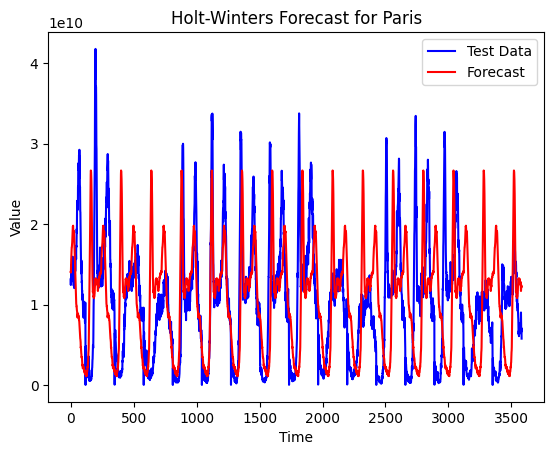

In [11]:
plt.plot(serv_1_test, label="Test Data", color='blue')
plt.plot(forecast, label="Forecast", color='red')
plt.title(f'Holt-Winters Forecast for {city}')
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()


In [32]:
forecasts = np.zeros((len(bordeaux[XTRAIN:]),servs))

In [6]:
servs= 5 

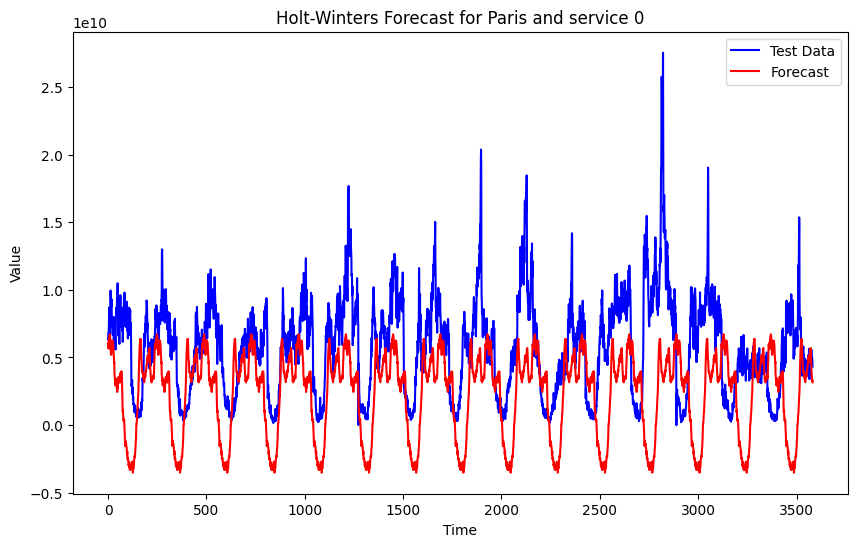

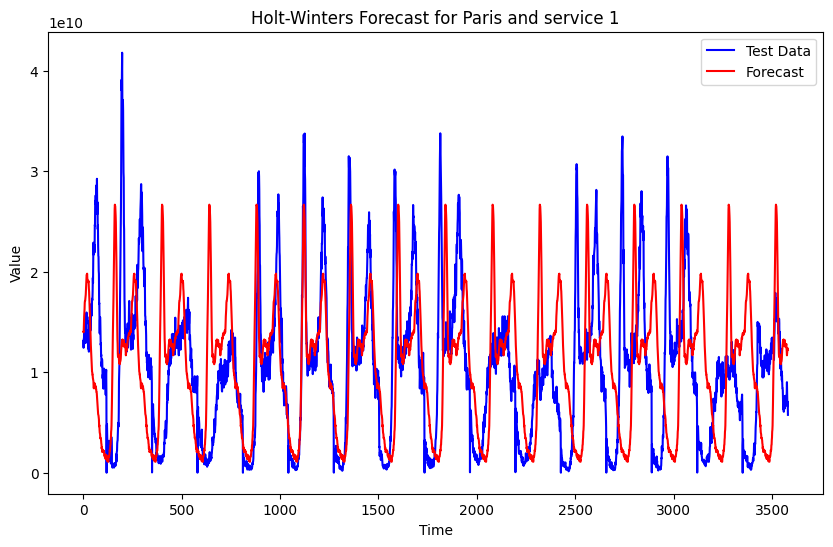

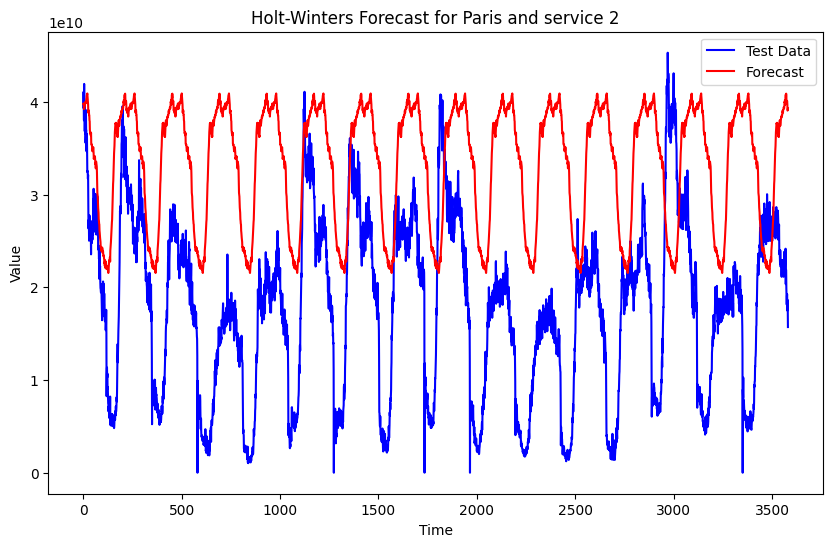

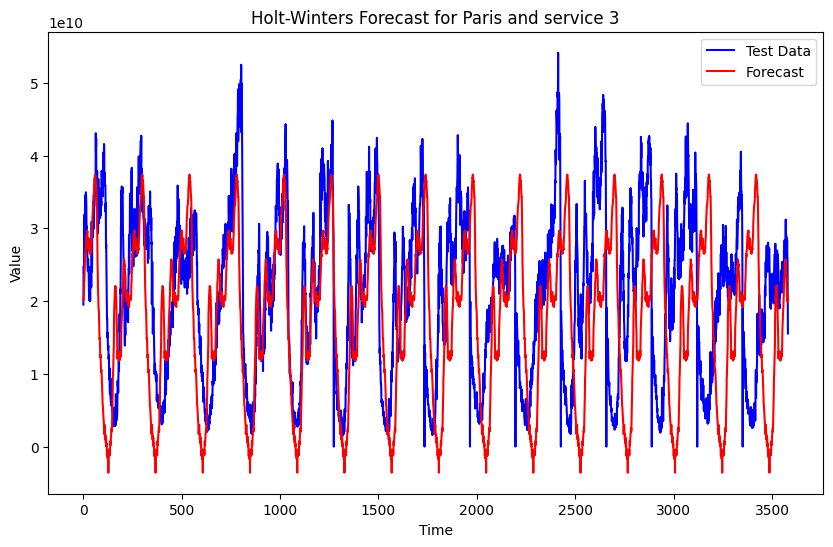

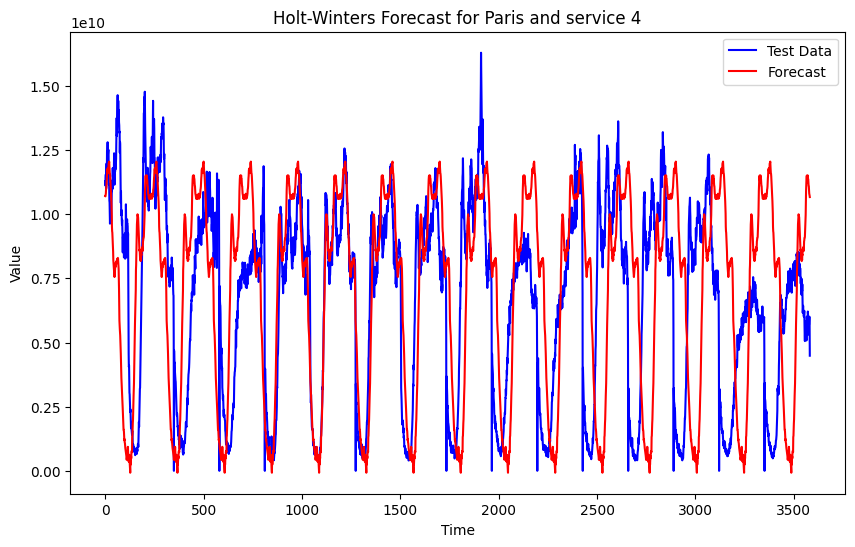

In [21]:
# forecasts = np.zeros((len(bordeaux[XTRAIN:]),servs))
for serv in range(servs):
   
    
    # serv_1_train = bordeaux[:XTRAIN,serv]
    serv_1_test = bordeaux[XTRAIN:,serv]
    # forecast = train_and_predict(serv_1_train, serv_1_test, seasonal_periods=240)
    # forecasts[:,serv] = forecast
    
    
    
    plt.figure(figsize=(10, 6))
    plt.plot(serv_1_test, label="Test Data", color='blue')
    plt.plot(forecasts[:,serv], label="Forecast", color='red')
    plt.title(f'Holt-Winters Forecast for {city} and service {serv}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()


In [13]:
Filesave = f'/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/{city}_Exp_Smooth_Forecast.npy'

# np.save(Filesave, forecasts)


In [19]:
forecasts = np.load(Filesave)

In [23]:
serv_1_test

array([1.12798676e+10, 1.11145207e+10, 1.14222115e+10, ...,
       6.00683477e+09, 5.72233089e+09, 4.48545905e+09])

In [ ]:
def load_scalers(city,delay):
    bench_scaler = pickle.load(open(f'/home/sergi_alcala/sergi_data/AZTEC_extension/{results_fpath}/{city}/Deepcog_benchmark_delay_{delay}_block_1_minmaxscaler.pkl', 'rb'))
    return bench_scaler

In [ ]:
results_fpath = 'Deepcog_Results'

In [29]:
### normalize the data using minmaxScaler
from sklearn.preprocessing import MinMaxScaler
minmaxscaler = MinMaxScaler()
x_test_norm =  minmaxscaler.fit_transform(bordeaux[XTRAIN:])
forecasts = minmaxscaler.fit_transform(forecasts)



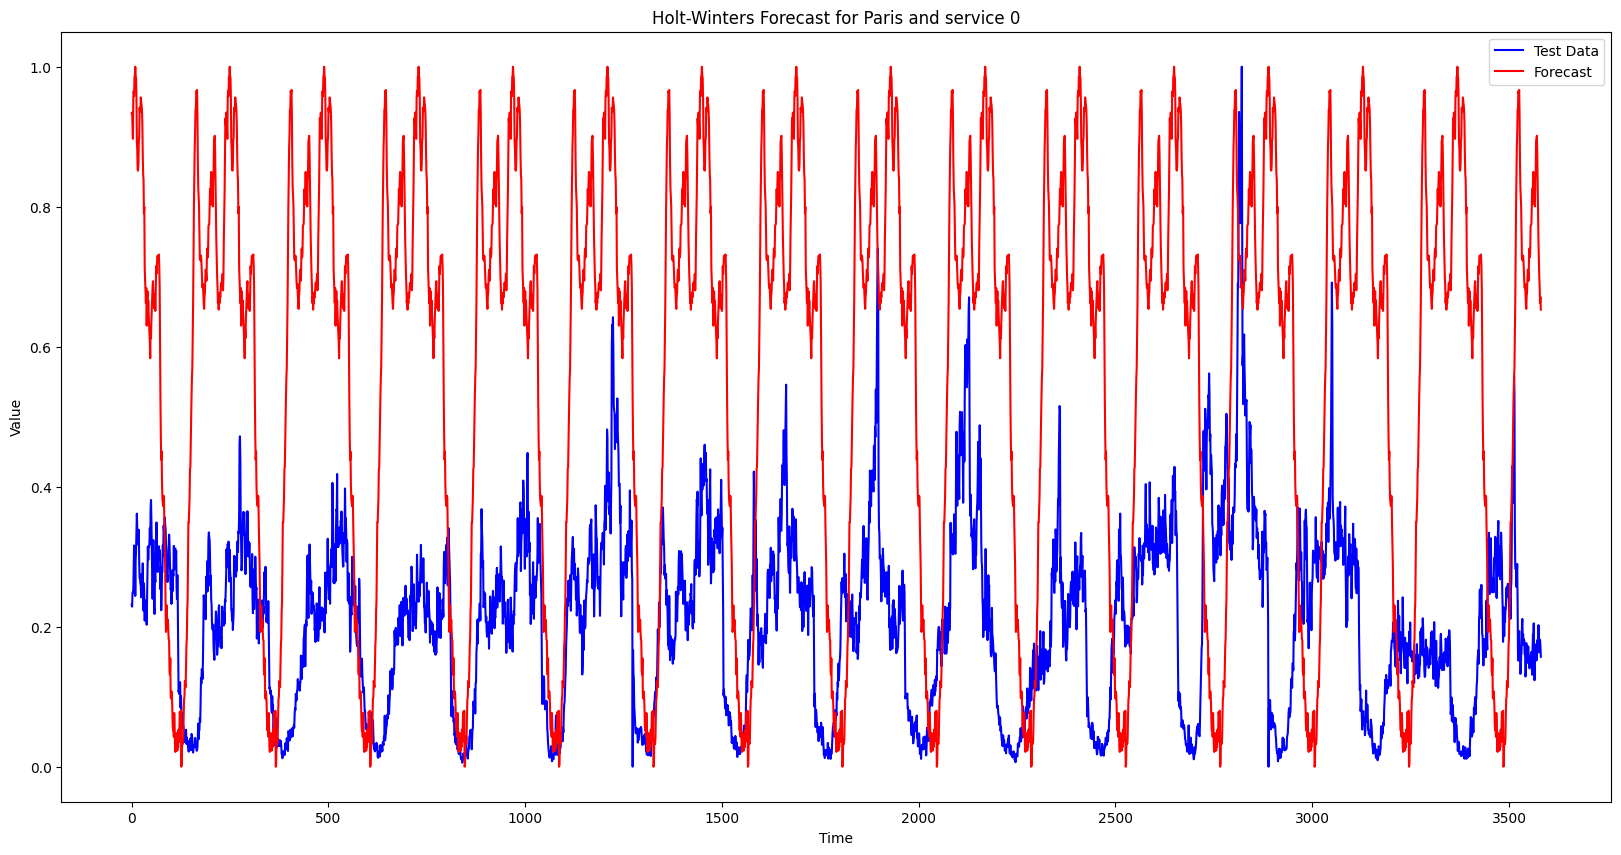

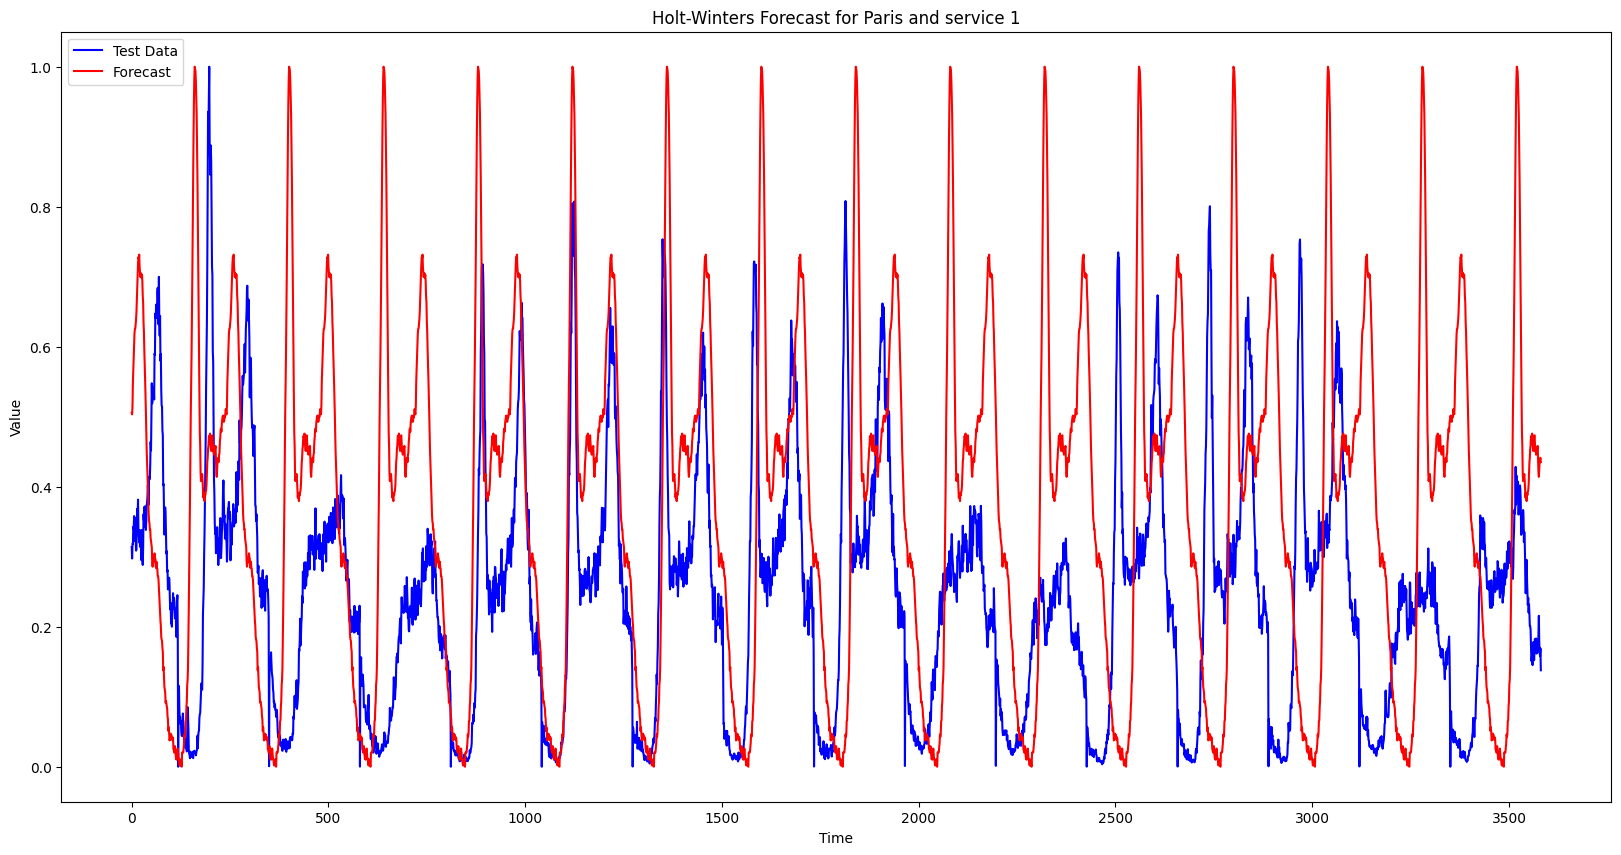

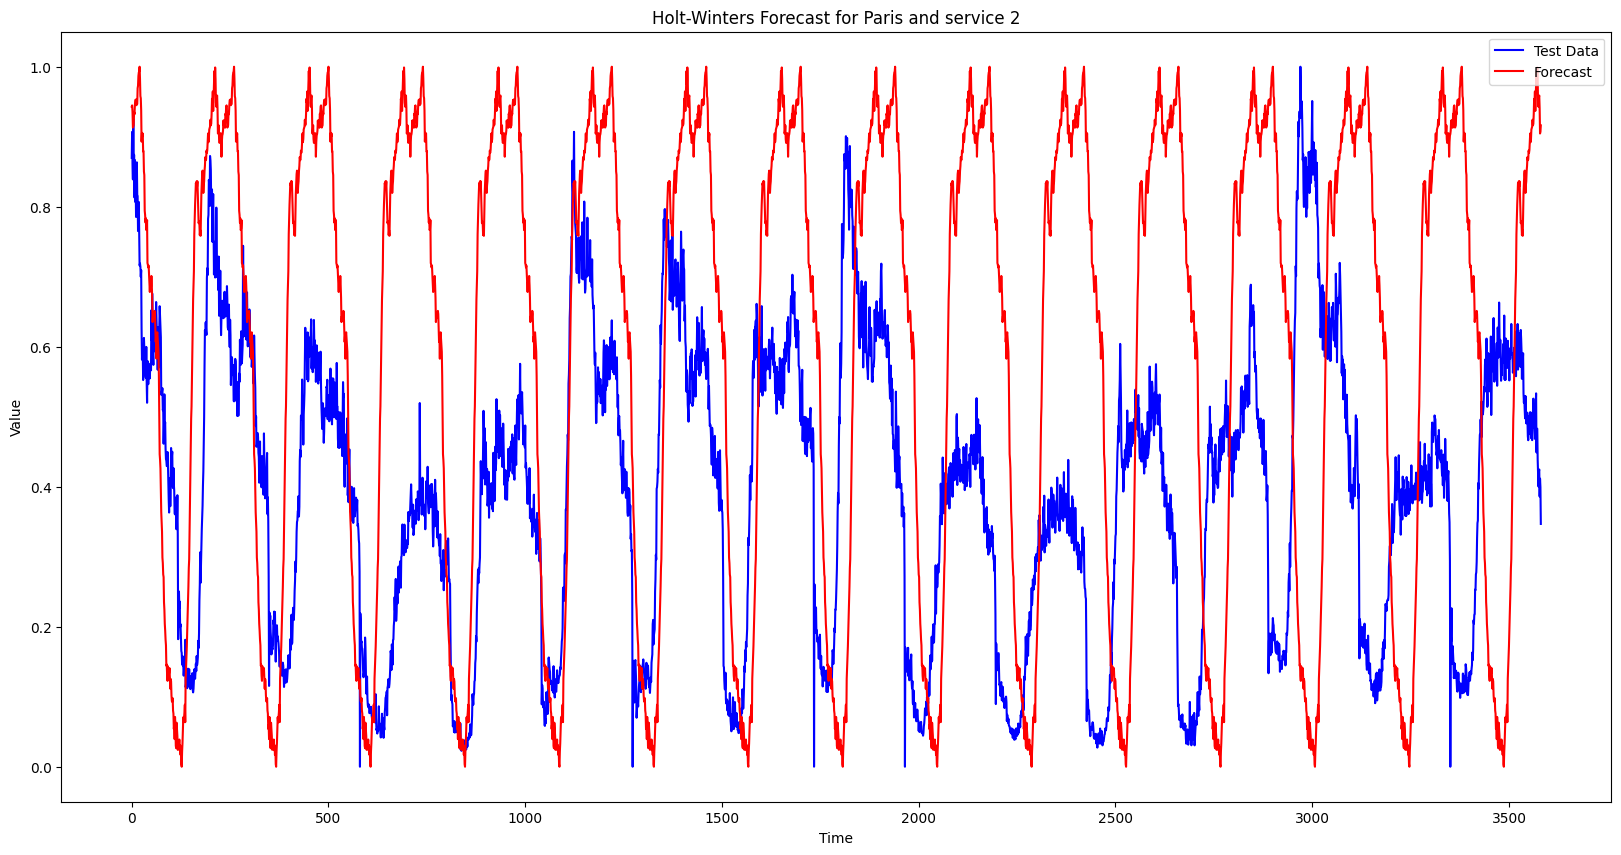

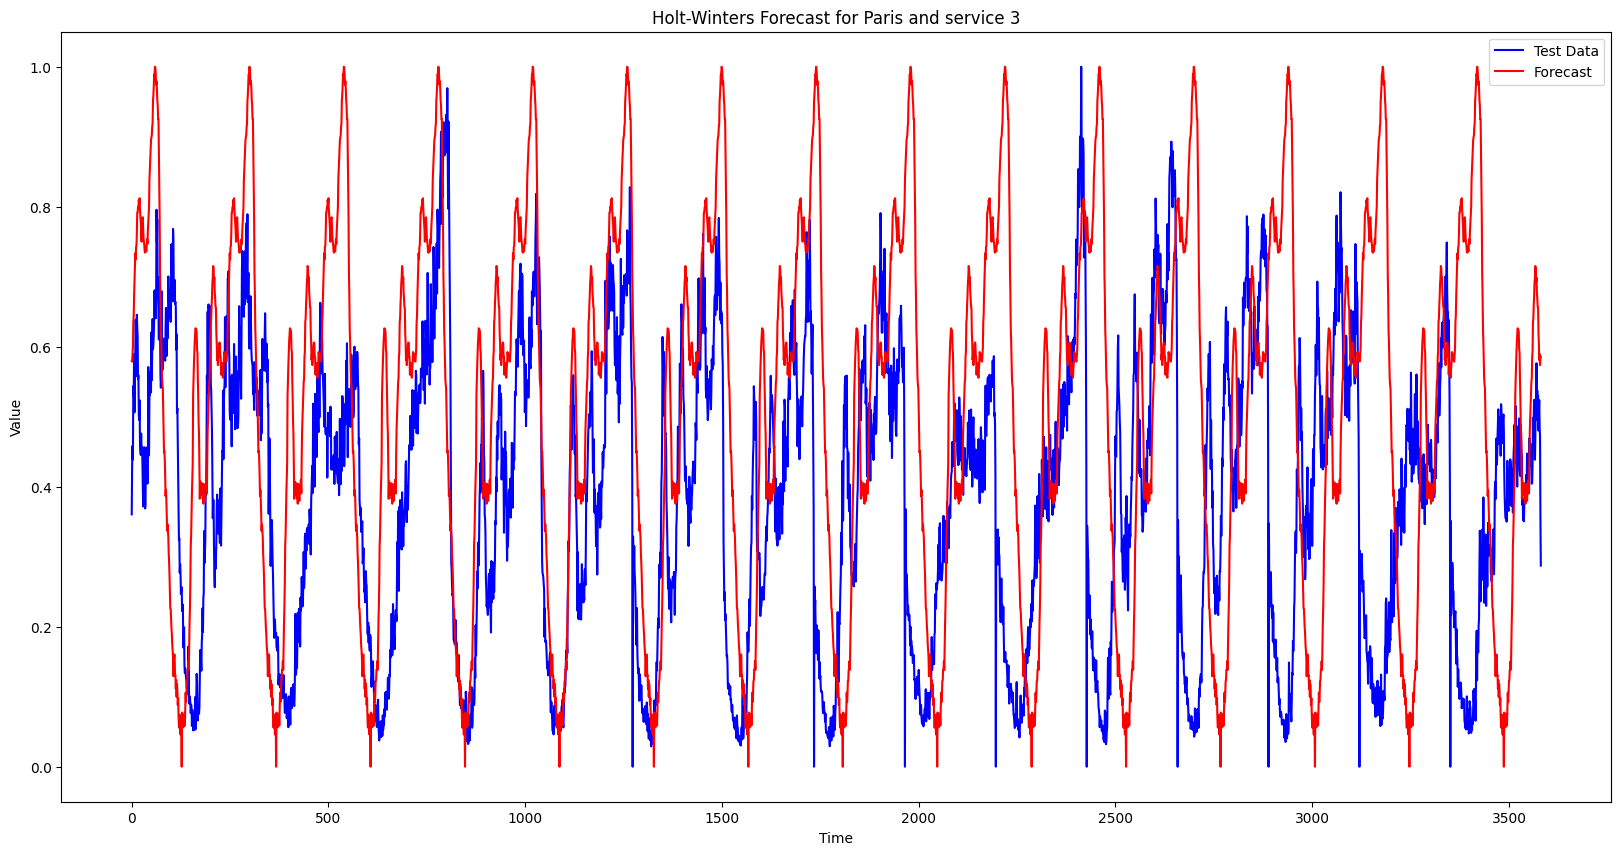

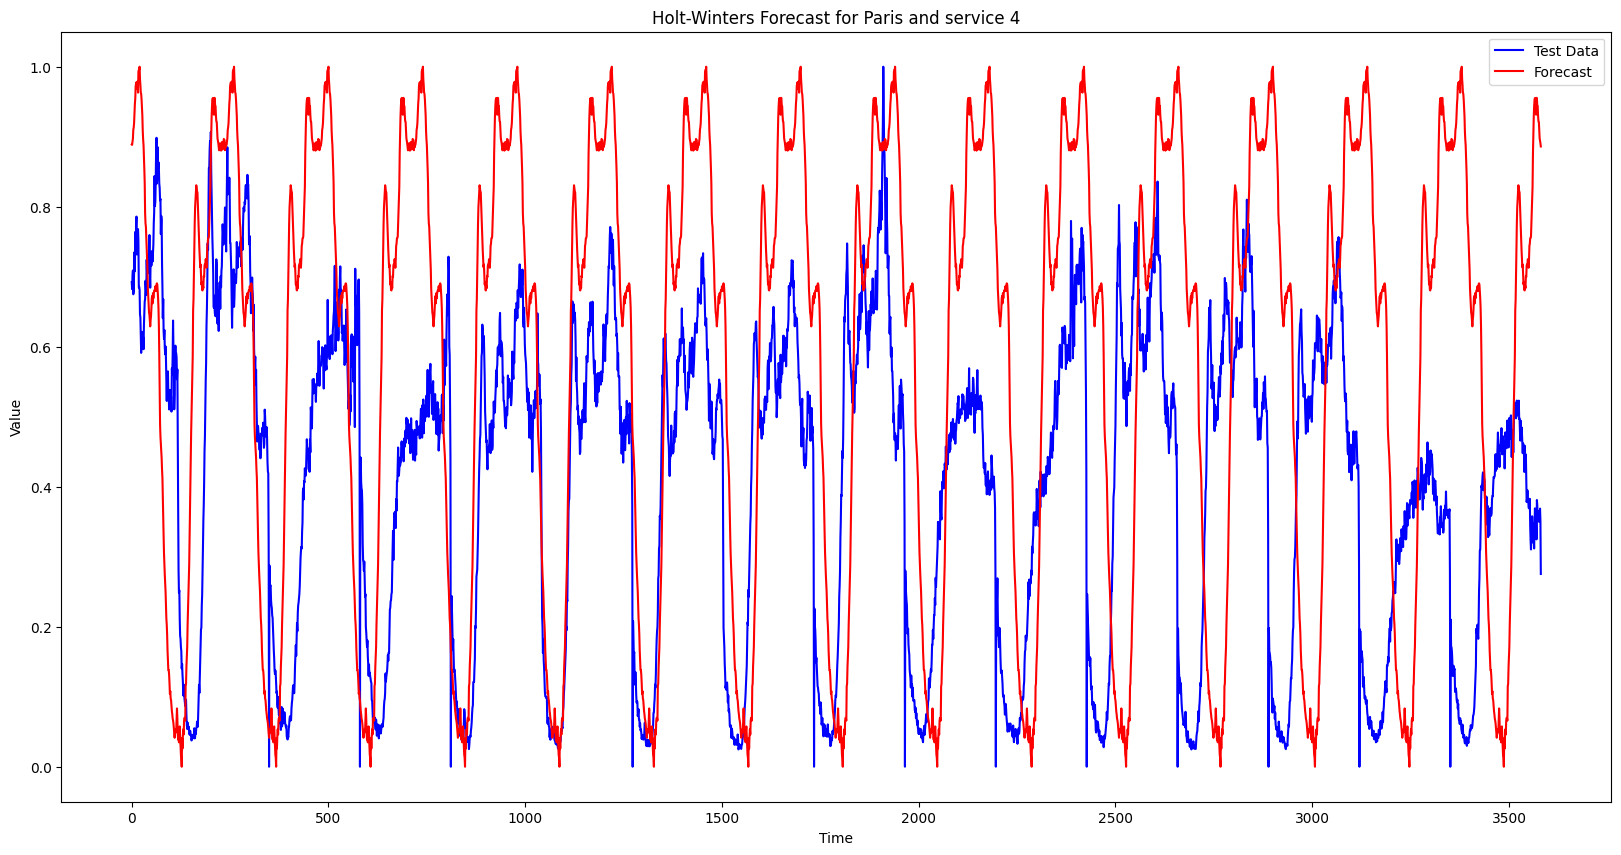

In [34]:
for serv in range(servs):
    plt.figure(figsize=(20, 10))
    plt.plot(x_test_norm[:,serv], label="Test Data", color='blue')
    plt.plot(forecasts[:,serv], label="Forecast", color='red')
    plt.title(f'Holt-Winters Forecast for {city} and service {serv}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()



In [30]:
## compute MSE between output and infocom
def mse(a, b):
    return np.mean((a - b) ** 2)

In [31]:
MSE = mse(forecasts, x_test_norm)
print(f'MSE for {city} is {MSE}')

MSE for Paris is 0.14309471505239224


In [27]:
#compute MSE
mse = np.zeros((servs))
for serv in range(servs):
    mse[serv] = np.mean((forecasts[:,serv] - bordeaux[XTRAIN:,serv])**2)
    # print(f'MSE for {city} and service {serv}: {mse[serv]}')

#now MSE for all services together
mse_all = np.mean(mse)
print(f'MSE for {city} all services: {mse_all}')

MSE for Paris all services: 1.300632537712247e+20


In [20]:
forecasts

array([[6.03625699e+09, 1.40153754e+10, 3.97930299e+10, 2.01547840e+10,
        1.07001914e+10],
       [6.04371463e+09, 1.39653472e+10, 3.98286595e+10, 2.01274175e+10,
        1.06952243e+10],
       [5.84499061e+09, 1.42889162e+10, 3.96503444e+10, 2.05639058e+10,
        1.07442960e+10],
       ...,
       [3.25898566e+09, 1.23419174e+10, 3.90510308e+10, 1.99244543e+10,
        1.07695978e+10],
       [3.34899854e+09, 1.23797317e+10, 3.91054544e+10, 2.03154785e+10,
        1.07240794e+10],
       [3.16225311e+09, 1.22222251e+10, 3.92758609e+10, 2.04022940e+10,
        1.06666429e+10]])

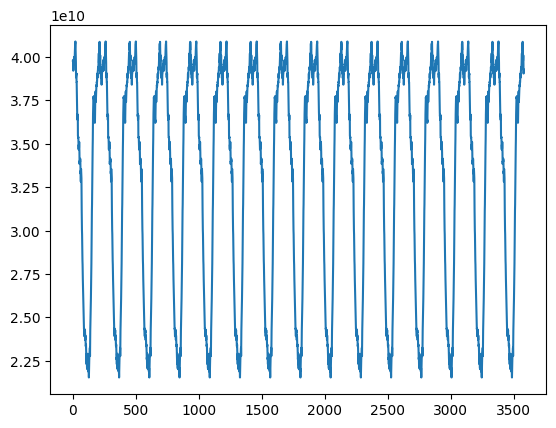

In [34]:
plt.plot(forecasts[:,2])

In [13]:
aaa= np.load(Filesave)

In [15]:
aaa.shape

(3582, 5)